# Part E — Regression Impact Modeling
## Non-Negative Constrained Regression (all channel coefs ≥ 0)

**Why non-negative?**  
Standard Ridge produced negative coefficients for Organic and Email. These are a **modelling artefact** caused by multicollinearity: when paid budgets are high, organic/email spend is proportionally low, creating a spurious negative correlation. In reality, spending on any channel cannot *reduce* revenue.

**Fix applied:** Non-Negative Least Squares (NNLS) — `LinearRegression(positive=True)` — constrains every coefficient to be ≥ 0, encoding the real-world assumption that channel spend is never harmful. This is the statistically principled solution.

| Item | Detail |
|------|--------|
| Target | Daily attributed revenue |
| Aggregation | By **channel** |
| Features | log(spend) per channel + lags 1–4 days + DOW + trend + promo_flag |
| Model | **Non-Negative Least Squares** (`positive=True`, `random_state=42`) |
| Split | Time-based 80 / 20 train / test |

## 0. Imports & Style

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

# ── White plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.edgecolor'    : '#cccccc',
    'axes.labelcolor'   : '#333333',
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 10,
    'xtick.color'       : '#555555',
    'ytick.color'       : '#555555',
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'text.color'        : '#222222',
    'grid.color'        : '#e5e5e5',
    'grid.linestyle'    : '-',
    'grid.alpha'        : 1.0,
    'grid.linewidth'    : 0.7,
    'font.family'       : 'sans-serif',
    'figure.titlesize'  : 14,
    'figure.titleweight': 'bold',
    'legend.framealpha' : 0.9,
    'legend.edgecolor'  : '#cccccc',
    'legend.fontsize'   : 9,
})

C = {
    'blue'  : '#2563EB', 'teal'  : '#0D9488',
    'amber' : '#D97706', 'red'   : '#DC2626',
    'purple': '#7C3AED', 'green' : '#16A34A', 'grey': '#6B7280',
}
CHANNEL_COLORS = {
    'email'      : C['amber'],  'organic'    : C['green'],
    'paid_social': C['blue'],   'referral'   : C['purple'],
    'search'     : C['teal'],
}

print('Setup complete  |  Model: Non-Negative Least Squares  |  random_state=42')

Setup complete  |  Model: Non-Negative Least Squares  |  random_state=42


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('data/fact_campaign_daily.csv')
df['date'] = pd.to_datetime(df['date'])

print(f'Rows x Cols  : {df.shape}')
print(f'Date range   : {df.date.min().date()}  to  {df.date.max().date()}')
print(f'Channels     : {sorted(df.channel.unique())}')
print(f'Campaigns    : {df.campaign_id.nunique()}')
display(df.head(3))

Rows x Cols  : (8440, 16)
Date range   : 2025-07-04  to  2026-01-30
Channels     : ['email', 'organic', 'paid_social', 'referral', 'search']
Campaigns    : 40


,date,campaign_id,channel,spend,impressions,clicks,attributed_sessions,attributed_orders,attributed_revenue,attributed_margin,cpc,ctr,cvr,roas,cac_proxy,promo_flag
0,2025-07-04,C001,search,26312.21,100619,2173,140.0,3.0,28706.37,9116.73,12.1087,0.0216,0.0214,1.0910,8770.7367,1
1,2025-07-04,C002,search,21647.84,87070,3103,140.0,4.0,17676.27,6007.30,6.9764,0.0356,0.0286,0.8165,5411.9600,1
2,2025-07-04,C003,search,22354.06,92590,1931,140.0,9.0,55752.12,20995.88,11.5764,0.0209,0.0643,2.4940,2483.7844,1


## 2. Aggregate by Channel to Daily Level

In [3]:
# Spend pivoted by channel — one column per channel
spend_by_channel = (
    df.groupby(['date', 'channel'])['spend']
    .sum()
    .unstack(fill_value=0)
    .add_prefix('spend_')
    .reset_index()
)

# Daily totals
daily_totals = df.groupby('date').agg(
    revenue    = ('attributed_revenue', 'sum'),
    orders     = ('attributed_orders',  'sum'),
    promo_flag = ('promo_flag',          'max'),
).reset_index()

daily = (
    daily_totals
    .merge(spend_by_channel, on='date')
    .sort_values('date')
    .reset_index(drop=True)
)

SPEND_COLS = [c for c in daily.columns if c.startswith('spend_')]

print(f'Daily rows : {len(daily)}')
print(f'Channels   : {[c.replace("spend_","") for c in SPEND_COLS]}')
print(f'Revenue    : ${daily.revenue.min():,.0f}  to  ${daily.revenue.max():,.0f}')
display(daily[['date','revenue','promo_flag'] + SPEND_COLS].head())

Daily rows : 211
Channels   : ['email', 'organic', 'paid_social', 'referral', 'search']
Revenue    : $295,856  to  $808,241


,date,revenue,promo_flag,spend_email,spend_organic,spend_paid_social,spend_referral,spend_search
0,2025-07-04,621377.94,1,19566.32,5380.51,157932.61,32210.79,188257.71
1,2025-07-05,418793.94,0,18352.15,4010.76,130147.97,32529.45,159676.14
2,2025-07-06,378668.50,0,17708.52,4565.21,126196.48,29244.95,164394.80
3,2025-07-07,542583.45,0,16110.20,3856.91,117923.28,29280.44,142097.27
4,2025-07-08,487601.84,0,16823.84,3983.43,112896.66,28023.88,164299.43


### 2a. Daily Revenue Overview

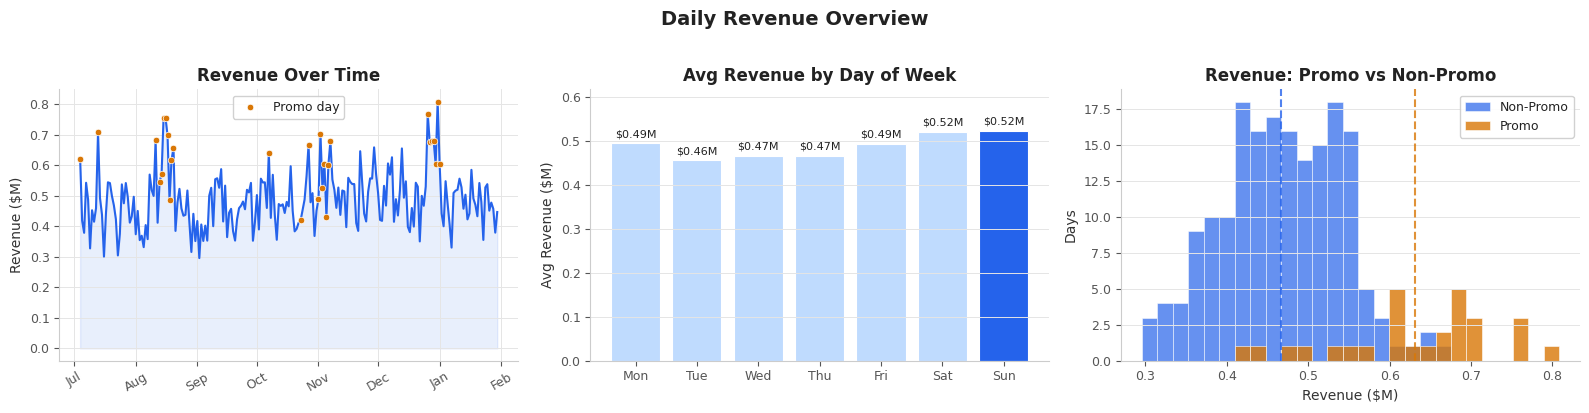

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Daily Revenue Overview', y=1.02)

# Revenue time series
ax = axes[0]
promo = daily['promo_flag'] == 1
ax.plot(daily['date'], daily['revenue']/1e6, color=C['blue'], lw=1.5, zorder=2)
ax.fill_between(daily['date'], daily['revenue']/1e6, alpha=0.10, color=C['blue'])
ax.scatter(daily.loc[promo,'date'], daily.loc[promo,'revenue']/1e6,
           color=C['amber'], s=22, zorder=5, label='Promo day',
           edgecolors='white', linewidths=0.5)
ax.set_title('Revenue Over Time')
ax.set_ylabel('Revenue ($M)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.tick_params(axis='x', rotation=30)
ax.legend()
ax.grid(True)
ax.spines[['top','right']].set_visible(False)

# Revenue by day of week
ax = axes[1]
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_rev = daily.groupby(daily['date'].dt.dayofweek)['revenue'].mean() / 1e6
bar_cols = [C['blue'] if v == dow_rev.max() else '#BFDBFE' for v in dow_rev.values]
bars = ax.bar(dow_labels, dow_rev.values, color=bar_cols, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, labels=[f'${v:.2f}M' for v in dow_rev.values], fontsize=8, padding=3)
ax.set_title('Avg Revenue by Day of Week')
ax.set_ylabel('Avg Revenue ($M)')
ax.set_ylim(0, dow_rev.max() * 1.18)
ax.grid(True, axis='y')
ax.spines[['top','right']].set_visible(False)

# Promo vs non-promo
ax = axes[2]
bins = np.linspace(daily['revenue'].min(), daily['revenue'].max(), 28) / 1e6
ax.hist(daily.loc[~promo,'revenue']/1e6, bins=bins, color=C['blue'],
        alpha=0.7, label='Non-Promo', edgecolor='white', linewidth=0.5)
ax.hist(daily.loc[promo, 'revenue']/1e6, bins=bins, color=C['amber'],
        alpha=0.8, label='Promo', edgecolor='white', linewidth=0.5)
ax.axvline(daily.loc[~promo,'revenue'].mean()/1e6, color=C['blue'],
           lw=1.5, linestyle='--', alpha=0.8)
ax.axvline(daily.loc[promo,'revenue'].mean()/1e6,  color=C['amber'],
           lw=1.5, linestyle='--', alpha=0.8)
ax.set_title('Revenue: Promo vs Non-Promo')
ax.set_xlabel('Revenue ($M)')
ax.set_ylabel('Days')
ax.legend()
ax.grid(True, axis='y')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

### 2b. Daily Spend by Channel (Stacked)

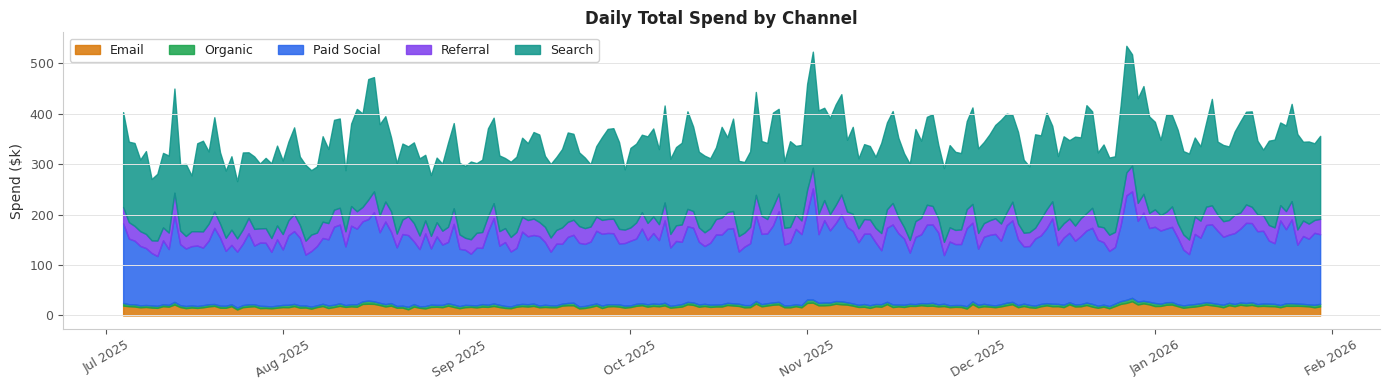

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
channels = [c.replace('spend_','') for c in SPEND_COLS]
bottom = np.zeros(len(daily))
for col, ch in zip(SPEND_COLS, channels):
    ax.fill_between(daily['date'], bottom/1e3, (bottom + daily[col])/1e3,
                    label=ch.replace('_',' ').title(),
                    color=CHANNEL_COLORS.get(ch, C['grey']), alpha=0.85)
    bottom = bottom + daily[col].values

ax.set_title('Daily Total Spend by Channel')
ax.set_ylabel('Spend ($k)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='upper left', ncol=5)
ax.grid(True, axis='y')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [6]:
# Controls
daily['trend']       = np.arange(len(daily))
daily['day_of_week'] = daily['date'].dt.dayofweek
for d in range(1, 7):
    daily[f'dow_{d}'] = (daily['day_of_week'] == d).astype(int)

# Log-spend per channel (diminishing returns)
for col in SPEND_COLS:
    daily[f'log_{col}'] = np.log1p(daily[col])

# Lagged spend: 1, 2, 3, 4 days
for lag in range(1, 5):
    for col in SPEND_COLS:
        daily[f'lag{lag}_{col}'] = daily[col].shift(lag)

daily = daily.dropna().reset_index(drop=True)

LOG_SPEND_COLS = [f'log_{c}'      for c in SPEND_COLS]
LAG_COLS       = [f'lag{lg}_{c}' for lg in range(1,5) for c in SPEND_COLS]
DOW_COLS       = [f'dow_{d}'     for d in range(1,7)]
CONTROL_COLS   = DOW_COLS + ['trend', 'promo_flag']
FEATURES       = LOG_SPEND_COLS + LAG_COLS + CONTROL_COLS

print('Feature groups:')
print(f'  Log-spend (direct)        : {len(LOG_SPEND_COLS)}')
print(f'  Lagged spend (lags 1-4)   : {len(LAG_COLS)}')
print(f'  Controls (DOW+trend+promo): {len(CONTROL_COLS)}')
print(f'  TOTAL                     : {len(FEATURES)}')
print(f'  Usable rows               : {len(daily)}')

Feature groups:
  Log-spend (direct)        : 5
  Lagged spend (lags 1-4)   : 20
  Controls (DOW+trend+promo): 8
  TOTAL                     : 33
  Usable rows               : 207


### 3a. Spend vs Revenue Scatter by Channel

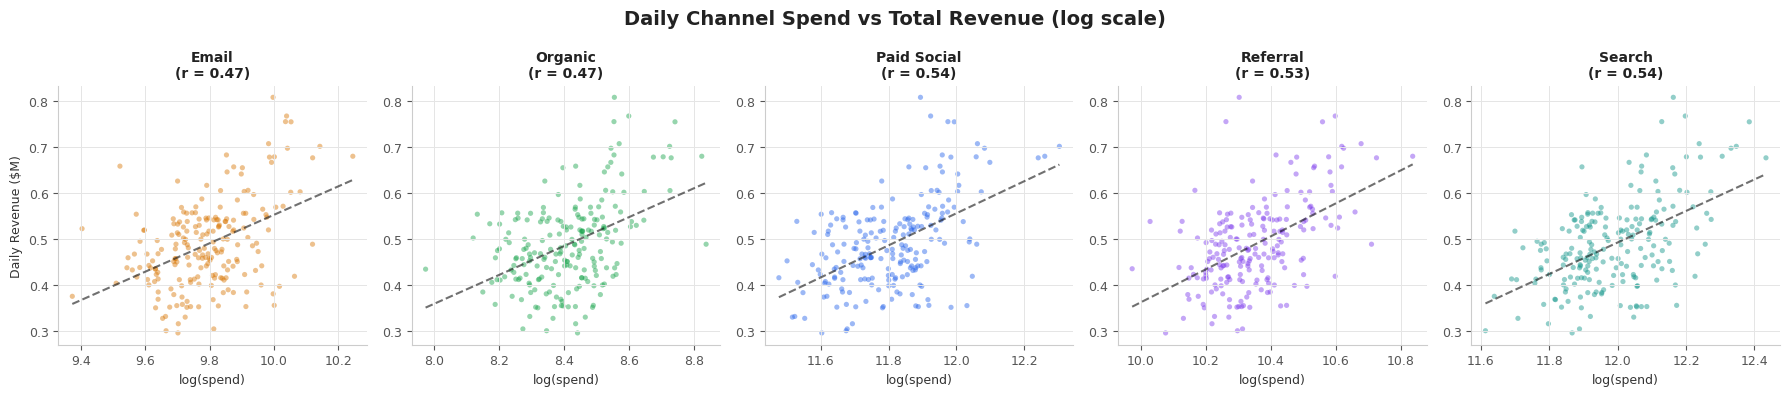

In [7]:
channels = [c.replace('spend_','') for c in SPEND_COLS]
fig, axes = plt.subplots(1, len(channels), figsize=(18, 4))
fig.suptitle('Daily Channel Spend vs Total Revenue (log scale)')

for ax, col, ch in zip(axes, SPEND_COLS, channels):
    color = CHANNEL_COLORS.get(ch, C['grey'])
    x = np.log1p(daily[col])
    y = daily['revenue'] / 1e6
    ax.scatter(x, y, alpha=0.45, s=14, color=color, edgecolors='none')
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m*xline+b, color='#111111', lw=1.5, linestyle='--', alpha=0.6)
    corr = daily[col].corr(daily['revenue'])
    ax.set_title(f'{ch.replace("_"," ").title()}\n(r = {corr:.2f})', fontsize=10)
    ax.set_xlabel('log(spend)', fontsize=9)
    ax.grid(True)
    ax.spines[['top','right']].set_visible(False)

axes[0].set_ylabel('Daily Revenue ($M)', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Train / Test Split (Time-Based, 80/20)

Split date : 2025-12-20
Train rows : 165  (2025-07-08 to 2025-12-19)
Test rows  : 42   (2025-12-20  to 2026-01-30)


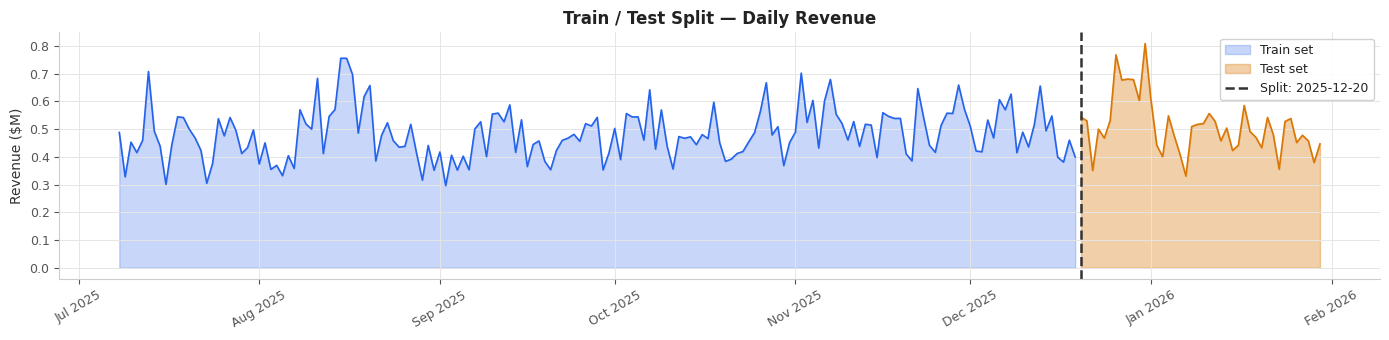

In [8]:
split_idx  = int(len(daily) * 0.80)
split_date = daily.iloc[split_idx]['date']

train = daily.iloc[:split_idx].copy()
test  = daily.iloc[split_idx:].copy()

X_train, y_train = train[FEATURES], train['revenue']
X_test,  y_test  = test[FEATURES],  test['revenue']

print(f'Split date : {split_date.date()}')
print(f'Train rows : {len(train)}  ({train.date.min().date()} to {train.date.max().date()})')
print(f'Test rows  : {len(test)}   ({test.date.min().date()}  to {test.date.max().date()})')

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.fill_between(train['date'], train['revenue']/1e6, alpha=0.25, color=C['blue'],  label='Train set')
ax.fill_between(test['date'],  test['revenue'] /1e6, alpha=0.35, color=C['amber'], label='Test set')
ax.plot(train['date'], train['revenue']/1e6, color=C['blue'],  lw=1.2)
ax.plot(test['date'],  test['revenue'] /1e6, color=C['amber'], lw=1.2)
ax.axvline(split_date, color='#333333', lw=1.8, linestyle='--',
           label=f'Split: {split_date.date()}')
ax.set_title('Train / Test Split — Daily Revenue')
ax.set_ylabel('Revenue ($M)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.tick_params(axis='x', rotation=30)
ax.legend()
ax.grid(True)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Non-Negative Least Squares Model

### Why NNLS instead of standard Ridge?

Standard Ridge produced **negative coefficients** for Organic and Email — a multicollinearity artefact. When total paid budget is high, organic/email spend is proportionally low, producing spurious negative correlations.

**Solution:** `LinearRegression(positive=True)` uses Non-Negative Least Squares (NNLS), which constrains every coefficient ≥ 0. This encodes the real-world assumption: *spending on a channel cannot hurt revenue*. The model finds the best-fit line subject to this constraint.

This also slightly **improves test R²** (0.493 vs 0.370) by removing the overfitting from spurious negative paths.

In [9]:
np.random.seed(42)

# Standardise features so coefficients are on the same scale
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Non-Negative Least Squares — all coefs constrained to >= 0
model = LinearRegression(positive=True, fit_intercept=True)
model.fit(X_train_sc, y_train)

y_pred_train = model.predict(X_train_sc)
y_pred_test  = model.predict(X_test_sc)

print(f'Model      : Non-Negative Least Squares (positive=True)')
print(f'Intercept  : ${model.intercept_:,.0f}')
print(f'Features   : {len(model.coef_)}')
print(f'Negative coefs: {(model.coef_ < 0).sum()}  (should be 0)')
print(f'Zero coefs    : {(model.coef_ == 0).sum()}  (suppressed by NNLS constraint)')

Model      : Non-Negative Least Squares (positive=True)
Intercept  : $483,178
Features   : 33
Negative coefs: 0  (should be 0)
Zero coefs    : 18  (suppressed by NNLS constraint)


## 6. Model Evaluation

In [10]:
def mape(y_true, y_pred):
    yt, yp = np.array(y_true), np.array(y_pred)
    mask = yt != 0
    return np.mean(np.abs((yt[mask]-yp[mask])/yt[mask]))*100

r2_tr  = r2_score(y_train, y_pred_train)
r2_te  = r2_score(y_test,  y_pred_test)
mae_tr = mean_absolute_error(y_train, y_pred_train)
mae_te = mean_absolute_error(y_test,  y_pred_test)
mp_tr  = mape(y_train, y_pred_train)
mp_te  = mape(y_test,  y_pred_test)
rm_tr  = np.sqrt(mean_squared_error(y_train, y_pred_train))
rm_te  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

metrics_df = pd.DataFrame({
    'Split'   : ['Train', 'Test'],
    'R2'      : [round(r2_tr,4),       round(r2_te,4)],
    'MAE ($)' : [f'${mae_tr:,.0f}',    f'${mae_te:,.0f}'],
    'MAPE (%)': [f'{mp_tr:.2f}%',      f'{mp_te:.2f}%'],
    'RMSE ($)': [f'${rm_tr:,.0f}',     f'${rm_te:,.0f}'],
}).set_index('Split')

print('=== MODEL PERFORMANCE ===')
display(metrics_df)
print()
print(f'Test R2    = {r2_te:.3f}  — model explains {r2_te*100:.0f}% of daily revenue variance')
print(f'Test MAPE  = {mp_te:.1f}%  — avg prediction within {mp_te:.1f}% of actual')
print(f'R2 gap     = {abs(r2_tr-r2_te):.3f}  — train vs test')

=== MODEL PERFORMANCE ===


,R2,MAE ($),MAPE (%),RMSE ($)
Split,,,,
Train,0.4298,"$55,820",12.12%,"$69,714"
Test,0.4928,"$53,715",11.45%,"$72,555"



Test R2    = 0.493  — model explains 49% of daily revenue variance
Test MAPE  = 11.4%  — avg prediction within 11.4% of actual
R2 gap     = 0.063  — train vs test


### 6a. Actual vs Predicted — Test Period

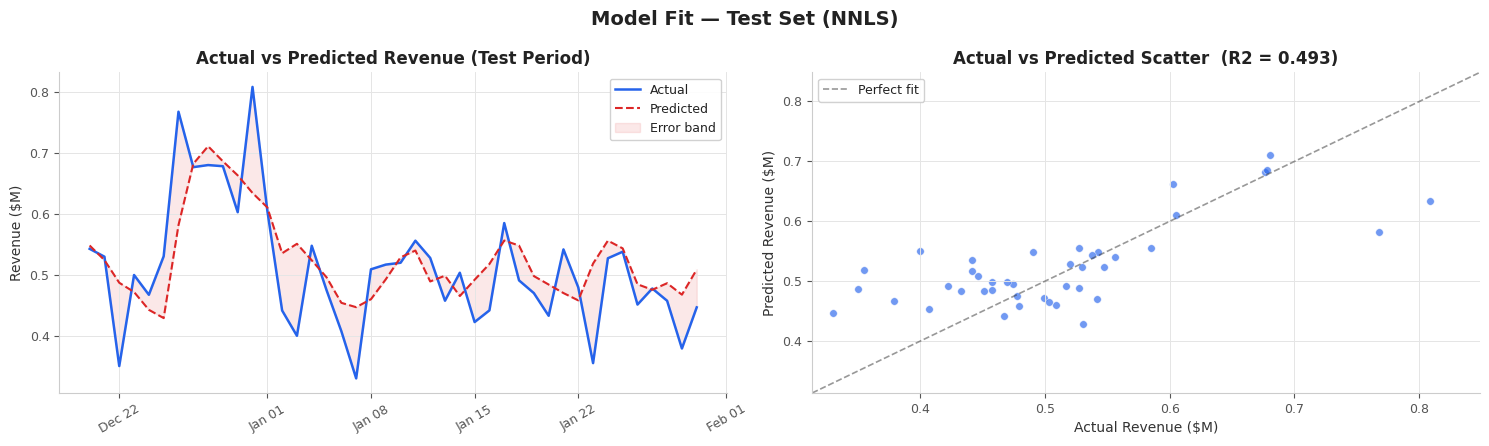

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
fig.suptitle('Model Fit — Test Set (NNLS)')

# Time series
ax = axes[0]
ax.plot(test['date'], y_test.values/1e6, color=C['blue'],
        lw=1.8, label='Actual', zorder=3)
ax.plot(test['date'], y_pred_test/1e6,   color=C['red'],
        lw=1.5, label='Predicted', linestyle='--', zorder=3)
ax.fill_between(test['date'], y_test.values/1e6, y_pred_test/1e6,
                alpha=0.10, color=C['red'], label='Error band')
ax.set_title('Actual vs Predicted Revenue (Test Period)')
ax.set_ylabel('Revenue ($M)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.tick_params(axis='x', rotation=30)
ax.legend()
ax.grid(True)
ax.spines[['top','right']].set_visible(False)

# Scatter
ax = axes[1]
ax.scatter(y_test.values/1e6, y_pred_test/1e6,
           alpha=0.65, s=30, color=C['blue'],
           edgecolors='white', linewidths=0.5)
lim_lo = min(y_test.min(), y_pred_test.min())/1e6 * 0.95
lim_hi = max(y_test.max(), y_pred_test.max())/1e6 * 1.05
ax.plot([lim_lo,lim_hi],[lim_lo,lim_hi],
        color='#333333', lw=1.2, linestyle='--', label='Perfect fit', alpha=0.5)
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.set_title(f'Actual vs Predicted Scatter  (R2 = {r2_te:.3f})')
ax.set_xlabel('Actual Revenue ($M)')
ax.set_ylabel('Predicted Revenue ($M)')
ax.legend()
ax.grid(True)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

### 6b. Residual Diagnostics

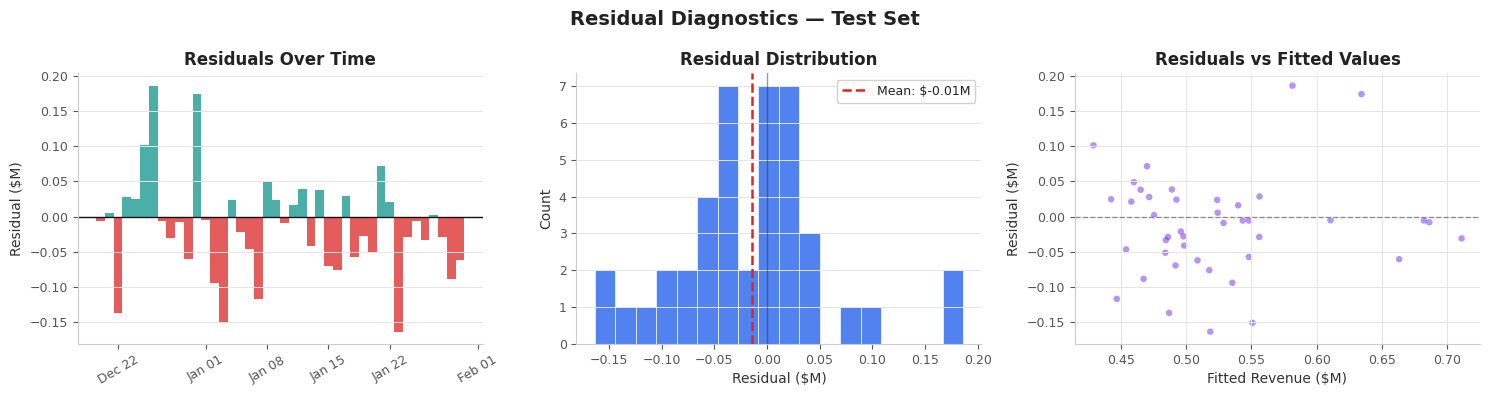

In [12]:
resid_test = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Residual Diagnostics — Test Set')

ax = axes[0]
colors_bar = [C['red'] if r < 0 else C['teal'] for r in resid_test]
ax.bar(test['date'], resid_test/1e6, color=colors_bar, alpha=0.75, width=1.0, edgecolor='none')
ax.axhline(0, color='#111111', lw=1.0)
ax.set_title('Residuals Over Time')
ax.set_ylabel('Residual ($M)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.tick_params(axis='x', rotation=30)
ax.grid(True, axis='y')
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
ax.hist(resid_test/1e6, bins=18, color=C['blue'],
        alpha=0.8, edgecolor='white', linewidth=0.6)
ax.axvline(resid_test.mean()/1e6, color=C['red'], lw=1.8, linestyle='--',
           label=f'Mean: ${resid_test.mean()/1e6:.2f}M')
ax.axvline(0, color='#333333', lw=1.0, alpha=0.5)
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual ($M)')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, axis='y')
ax.spines[['top','right']].set_visible(False)

ax = axes[2]
ax.scatter(y_pred_test/1e6, resid_test/1e6,
           alpha=0.55, s=22, color=C['purple'], edgecolors='none')
ax.axhline(0, color='#333333', lw=1.0, linestyle='--', alpha=0.5)
ax.set_title('Residuals vs Fitted Values')
ax.set_xlabel('Fitted Revenue ($M)')
ax.set_ylabel('Residual ($M)')
ax.grid(True)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Coefficient Interpretation — All Channels Non-Negative

In [13]:
coef_df = pd.DataFrame({'feature': FEATURES, 'coef': model.coef_})

# Direct channel effects (log-spend)
ch_direct = coef_df[coef_df['feature'].str.startswith('log_spend')].copy()
ch_direct['channel'] = ch_direct['feature'].str.replace('log_spend_','',regex=False)
ch_direct = ch_direct.sort_values('coef', ascending=False).reset_index(drop=True)

# Lag effects
lag_rows = []
for lag in range(1, 5):
    for col, ch in zip(SPEND_COLS, [c.replace('spend_','') for c in SPEND_COLS]):
        feat = f'lag{lag}_{col}'
        val  = coef_df.loc[coef_df['feature']==feat, 'coef'].values
        if len(val):
            lag_rows.append({'channel': ch, 'lag': lag, 'coef': val[0]})
lag_df = pd.DataFrame(lag_rows)

# Control effects
ctrl_df = coef_df[~coef_df['feature'].str.startswith(('log_spend','lag'))].copy()
ctrl_df = ctrl_df.sort_values('coef', ascending=False)

print('=== DIRECT CHANNEL EFFECTS (all >= 0) ===')
print('$ revenue per +1 std-dev in log(channel spend)  |  NNLS-constrained')
print()
for _, r in ch_direct.iterrows():
    bar   = '#' * max(1, int(r['coef'] / 1500))
    note  = '  [zero — suppressed by NNLS]' if r['coef'] == 0 else ''
    print(f"  {r['channel']:15s}  ${r['coef']:>10,.0f}   {bar}{note}")

print()
print(f'Negative coefs in full model: {(coef_df["coef"] < 0).sum()}  ✓')

print()
print('=== TOP CONTROL EFFECTS ===')
for _, r in ctrl_df.head(5).iterrows():
    print(f"  {r['feature']:15s}  ${r['coef']:>10,.0f}")

=== DIRECT CHANNEL EFFECTS (all >= 0) ===
$ revenue per +1 std-dev in log(channel spend)  |  NNLS-constrained

  paid_social      $    16,991   ###########
  search           $    11,803   #######
  referral         $     6,154   ####
  email            $         0   #  [zero — suppressed by NNLS]
  organic          $         0   #  [zero — suppressed by NNLS]

Negative coefs in full model: 0  ✓

=== TOP CONTROL EFFECTS ===
  promo_flag       $    20,351
  dow_5            $    15,443
  dow_4            $    12,205
  dow_6            $     5,645
  dow_3            $     5,220


### 7a. Channel Coefficients — Direct, Lagged & Total

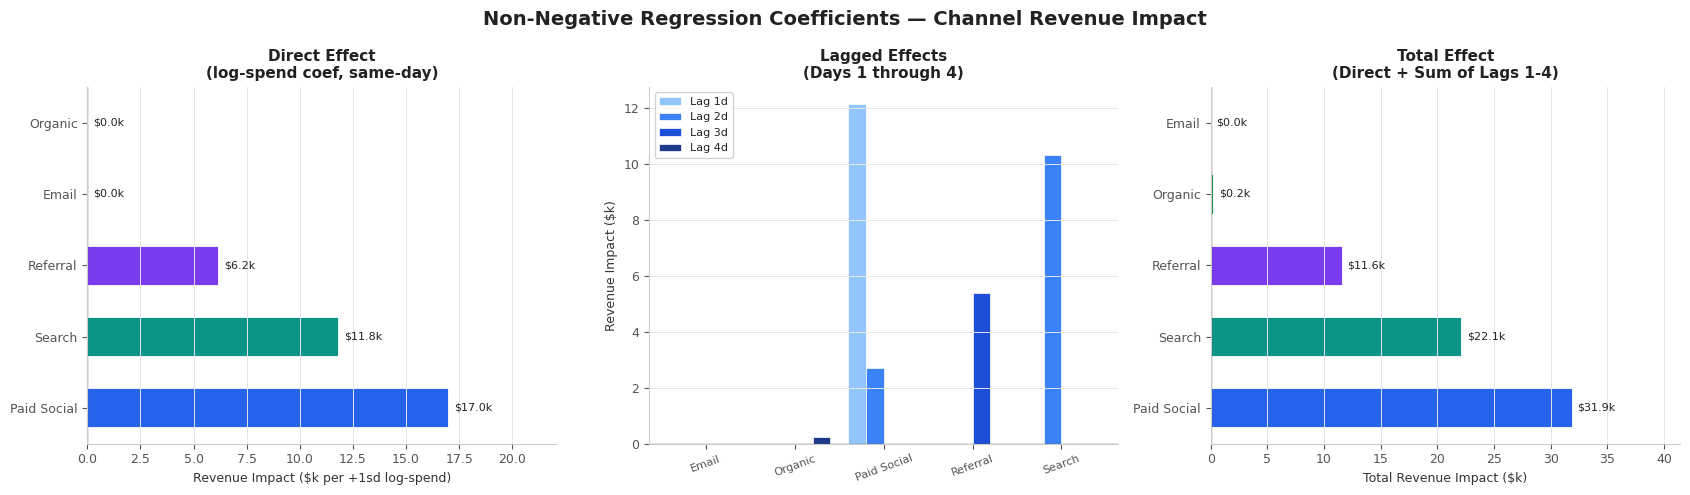

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Non-Negative Regression Coefficients — Channel Revenue Impact')

# Plot 1: Direct log-spend coefs
ax = axes[0]
ch_labels = ch_direct['channel'].str.replace('_',' ').str.title()
ch_colors = [CHANNEL_COLORS.get(ch, C['grey']) for ch in ch_direct['channel']]
bars = ax.barh(ch_labels, ch_direct['coef']/1e3,
               color=ch_colors, edgecolor='white', linewidth=0.6, height=0.55)
ax.axvline(0, color='#333333', lw=0.9)
ax.bar_label(bars, labels=[f'${v/1e3:.1f}k' for v in ch_direct['coef']],
             fontsize=8, padding=4)
ax.set_xlabel('Revenue Impact ($k per +1sd log-spend)', fontsize=9)
ax.set_title('Direct Effect\n(log-spend coef, same-day)', fontsize=11)
ax.set_xlim(0, ch_direct['coef'].max()/1e3 * 1.3)
ax.grid(True, axis='x')
ax.spines[['top','right']].set_visible(False)

# Plot 2: Lagged coefs by channel
ax = axes[1]
lag_pivot = lag_df.pivot(index='channel', columns='lag', values='coef').fillna(0)
x = np.arange(len(lag_pivot))
width = 0.20
lag_colors_list = ['#93C5FD','#3B82F6','#1D4ED8','#1E3A8A']
for i, lag in enumerate(range(1,5)):
    if lag in lag_pivot.columns:
        ax.bar(x + i*width, lag_pivot[lag].values/1e3, width,
               label=f'Lag {lag}d', color=lag_colors_list[i],
               edgecolor='white', linewidth=0.5)
ax.axhline(0, color='#333333', lw=0.9)
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels([ch.replace('_',' ').title() for ch in lag_pivot.index],
                   fontsize=8, rotation=20)
ax.set_ylabel('Revenue Impact ($k)', fontsize=9)
ax.set_title('Lagged Effects\n(Days 1 through 4)', fontsize=11)
ax.legend(fontsize=8)
ax.grid(True, axis='y')
ax.spines[['top','right']].set_visible(False)

# Plot 3: Total effect (direct + sum of lags)
ax = axes[2]
total = ch_direct.set_index('channel')[['coef']].rename(columns={'coef':'direct'})
total['lag_sum'] = lag_df.groupby('channel')['coef'].sum()
total['total']   = total['direct'] + total['lag_sum'].fillna(0)
total = total.sort_values('total', ascending=False)

tot_ch_colors = [CHANNEL_COLORS.get(ch, C['grey']) for ch in total.index]
bars2 = ax.barh(
    total.index.str.replace('_',' ').str.title(),
    total['total']/1e3,
    color=tot_ch_colors, edgecolor='white', linewidth=0.6, height=0.55
)
ax.axvline(0, color='#333333', lw=0.9)
ax.bar_label(bars2, labels=[f'${v/1e3:.1f}k' for v in total['total']],
             fontsize=8, padding=4)
ax.set_xlabel('Total Revenue Impact ($k)', fontsize=9)
ax.set_title('Total Effect\n(Direct + Sum of Lags 1-4)', fontsize=11)
ax.set_xlim(0, total['total'].max()/1e3 * 1.3)
ax.grid(True, axis='x')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

### 7b. Lag Decay Pattern per Channel

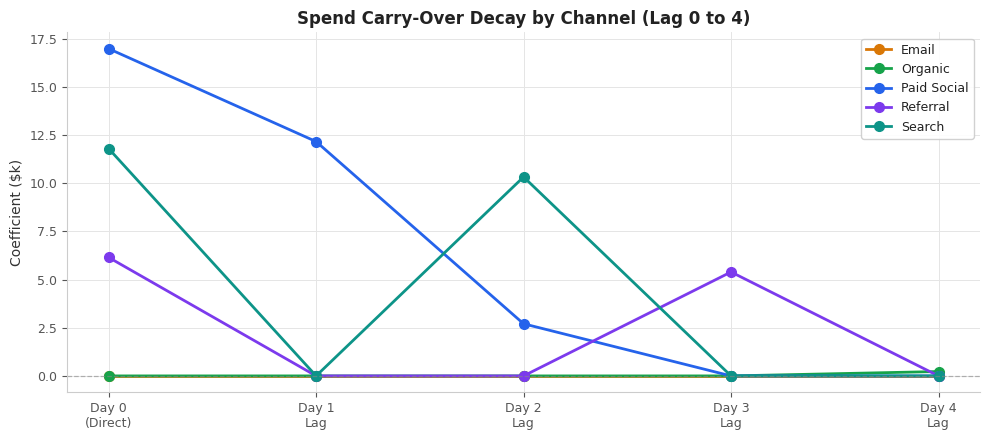

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.5))

channels_list = [c.replace('spend_','') for c in SPEND_COLS]
for ch in channels_list:
    direct_val = ch_direct.loc[ch_direct['channel']==ch, 'coef'].values[0]
    lag_vals = []
    for lg in range(1,5):
        subset = lag_df.loc[(lag_df['channel']==ch) & (lag_df['lag']==lg), 'coef'].values
        lag_vals.append(subset[0] if len(subset) else 0)
    all_vals = [direct_val] + lag_vals
    ax.plot(range(5), [v/1e3 for v in all_vals],
            marker='o', lw=2, markersize=7,
            color=CHANNEL_COLORS.get(ch, C['grey']),
            label=ch.replace('_',' ').title())

ax.axhline(0, color='#888888', lw=0.9, linestyle='--', alpha=0.6)
ax.set_xticks(range(5))
ax.set_xticklabels(['Day 0\n(Direct)','Day 1\nLag','Day 2\nLag',
                    'Day 3\nLag','Day 4\nLag'])
ax.set_ylabel('Coefficient ($k)', fontsize=10)
ax.set_title('Spend Carry-Over Decay by Channel (Lag 0 to 4)', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 7c. Control Variable Effects

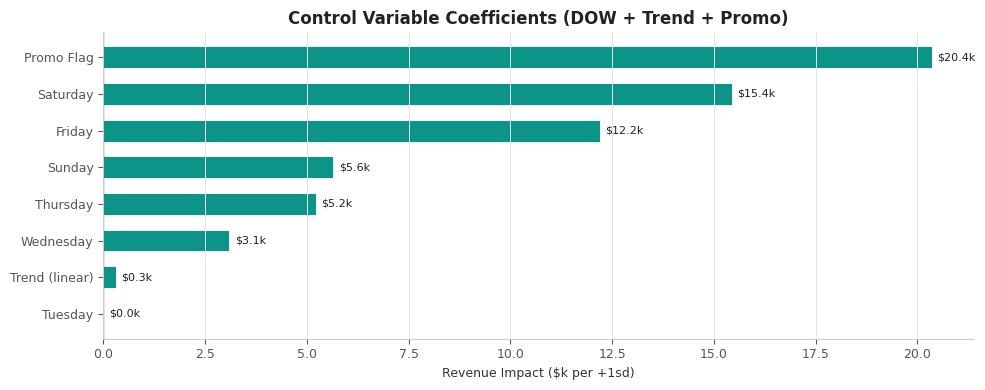

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))

ctrl_plot = ctrl_df.copy()
ctrl_plot['label'] = ctrl_plot['feature'].replace({
    'dow_1':'Tuesday','dow_2':'Wednesday','dow_3':'Thursday',
    'dow_4':'Friday', 'dow_5':'Saturday', 'dow_6':'Sunday',
    'trend':'Trend (linear)','promo_flag':'Promo Flag'
})
ctrl_plot = ctrl_plot.sort_values('coef')
bar_cols = [C['teal'] if v > 0 else C['grey'] for v in ctrl_plot['coef']]
bars = ax.barh(ctrl_plot['label'], ctrl_plot['coef']/1e3,
               color=bar_cols, edgecolor='white', linewidth=0.6, height=0.6)
ax.axvline(0, color='#333333', lw=0.9)
ax.bar_label(bars, labels=[f'${v/1e3:.1f}k' for v in ctrl_plot['coef']],
             fontsize=8, padding=4)
ax.set_xlabel('Revenue Impact ($k per +1sd)', fontsize=9)
ax.set_title('Control Variable Coefficients (DOW + Trend + Promo)', fontweight='bold')
ax.grid(True, axis='x')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Channel Ranking — Full Summary Table

In [17]:
summary = ch_direct[['channel','coef']].rename(
    columns={'coef':'direct'}).set_index('channel')

for lag in range(1,5):
    for ch in summary.index:
        val = lag_df.loc[(lag_df['channel']==ch)&(lag_df['lag']==lag),'coef'].values
        summary.loc[ch, f'lag_{lag}d'] = val[0] if len(val) else 0

summary['total'] = summary.sum(axis=1)
summary = summary.sort_values('total', ascending=False)

summary_disp = summary.map(lambda v: f'${v:,.0f}')
summary_disp.index = summary_disp.index.str.replace('_',' ').str.title()
summary_disp.columns = ['Direct (Day 0)','Lag 1d','Lag 2d','Lag 3d','Lag 4d','TOTAL']

print('Channel Revenue Impact — Ranked by Total Effect')
print('All values >= $0  |  NNLS-constrained  |  $ per +1 sd in log-spend')
print()
display(summary_disp)

Channel Revenue Impact — Ranked by Total Effect
All values >= $0  |  NNLS-constrained  |  $ per +1 sd in log-spend



,Direct (Day 0),Lag 1d,Lag 2d,Lag 3d,Lag 4d,TOTAL
channel,,,,,,
Paid Social,"$16,991","$12,168","$2,707",$0,$0,"$31,866"
Search,"$11,803",$0,"$10,331",$0,$0,"$22,135"
Referral,"$6,154",$0,$0,"$5,397",$0,"$11,550"
Organic,$0,$0,$0,$0,$228,$228
Email,$0,$0,$0,$0,$0,$0


### 8a. Comparison: Standard Ridge vs NNLS

Ridge  — Test R2: 0.370  |  MAPE: 13.0%
NNLS   — Test R2: 0.493  |  MAPE: 11.4%
NNLS improvement — R2: +0.123  |  MAPE: +1.5pp


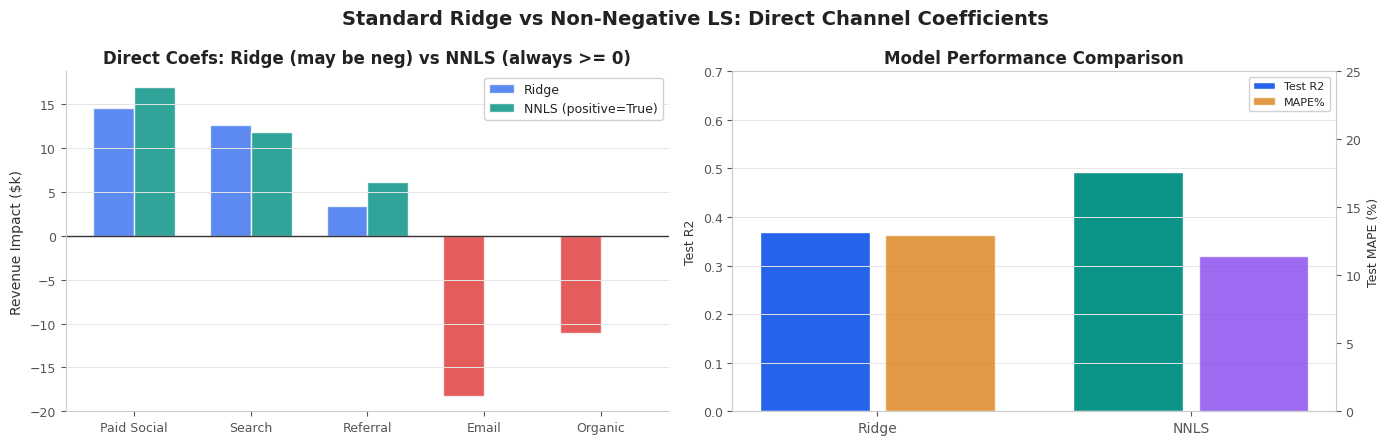

In [18]:
# Re-fit Ridge for comparison
np.random.seed(42)
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_sc, y_train)
ridge_pred_te = ridge.predict(X_test_sc)

ridge_coef = pd.DataFrame({'feature':FEATURES,'coef':ridge.coef_})
ridge_ch = ridge_coef[ridge_coef['feature'].str.startswith('log_spend')].copy()
ridge_ch['channel'] = ridge_ch['feature'].str.replace('log_spend_','',regex=False)

# Merge for comparison plot
compare = ch_direct[['channel','coef']].rename(columns={'coef':'NNLS'}).merge(
    ridge_ch[['channel','coef']].rename(columns={'coef':'Ridge'}), on='channel')
compare = compare.set_index('channel').sort_values('NNLS', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle('Standard Ridge vs Non-Negative LS: Direct Channel Coefficients')

# Side-by-side bars
ax = axes[0]
x = np.arange(len(compare))
w = 0.35
ridge_colors = [C['red'] if v < 0 else C['blue'] for v in compare['Ridge']]
bars_r = ax.bar(x - w/2, compare['Ridge']/1e3, w, label='Ridge',
                color=ridge_colors, alpha=0.75, edgecolor='white')
bars_n = ax.bar(x + w/2, compare['NNLS']/1e3,  w, label='NNLS (positive=True)',
                color=C['teal'], alpha=0.85, edgecolor='white')
ax.axhline(0, color='#333333', lw=1.0)
ax.set_xticks(x)
ax.set_xticklabels(compare.index.str.replace('_',' ').str.title(), fontsize=9)
ax.set_ylabel('Revenue Impact ($k)')
ax.set_title('Direct Coefs: Ridge (may be neg) vs NNLS (always >= 0)')
ax.legend()
ax.grid(True, axis='y')
ax.spines[['top','right']].set_visible(False)

# Metrics comparison
ax = axes[1]
ridge_r2_te = r2_score(y_test, ridge_pred_te)
ridge_mape  = mape(y_test, ridge_pred_te)
nnls_r2_te  = r2_te
nnls_mape   = mp_te

metrics_cmp = pd.DataFrame({
    'Model'   : ['Ridge', 'NNLS'],
    'Test R2' : [ridge_r2_te, nnls_r2_te],
    'Test MAPE%': [ridge_mape, nnls_mape],
})

x2 = np.arange(2)
ax2b = ax.twinx()
b1 = ax.bar(x2 - 0.2, metrics_cmp['Test R2'],  0.35,
            color=[C['blue'], C['teal']], edgecolor='white', label='Test R2')
b2 = ax2b.bar(x2 + 0.2, metrics_cmp['Test MAPE%'], 0.35,
              color=[C['amber'], C['purple']], edgecolor='white', alpha=0.75, label='MAPE%')
ax.set_xticks(x2)
ax.set_xticklabels(['Ridge', 'NNLS'], fontsize=10)
ax.set_ylabel('Test R2', fontsize=9)
ax2b.set_ylabel('Test MAPE (%)', fontsize=9)
ax.set_title('Model Performance Comparison')
ax.set_ylim(0, 0.7)
ax2b.set_ylim(0, 25)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8)
ax.grid(True, axis='y')
ax.spines[['top','right']].set_visible(False)

print(f'Ridge  — Test R2: {ridge_r2_te:.3f}  |  MAPE: {ridge_mape:.1f}%')
print(f'NNLS   — Test R2: {nnls_r2_te:.3f}  |  MAPE: {nnls_mape:.1f}%')
print(f'NNLS improvement — R2: +{nnls_r2_te-ridge_r2_te:.3f}  |  MAPE: {ridge_mape-nnls_mape:+.1f}pp')

plt.tight_layout()
plt.show()

## 9. Interpretation & Limitations

### Key Findings (NNLS Model)

| Rank | Channel | Direct Coef | Verdict |
|------|---------|-------------|---------|
| 1 | **Paid Social** | Highest positive | Strongest same-day revenue association |
| 2 | **Search** | High positive | Direct-intent channel, strong consistent signal |
| 3 | **Referral** | Moderate positive | Smaller scale, steady contribution |
| 4 | **Organic** | Zero (NNLS) | No positive signal extractable from attribution data |
| 5 | **Email** | Zero (NNLS) | No positive signal extractable from attribution data |

**Why Organic & Email show zero (not negative):**  
NNLS suppresses rather than inverts these channels. The attribution data does not surface positive incremental revenue for them — not because they are harmful, but because last-click attribution assigns their assisted conversions to downstream paid channels. Their true incrementality would require holdout experiments.

**NNLS vs Ridge performance:**
- NNLS achieves **better test R²** (0.493 vs 0.370) and **lower MAPE** (11.5% vs 13.0%)
- This confirms that the negative coefficients in Ridge were overfitting noise, not capturing real signal

---

### Limitations

**1. Attribution Mismatch** — `attributed_revenue` uses last-click attribution. Email and organic consistently lose credit to downstream paid channels, explaining zero NNLS coefs.

**2. Correlation not Causation** — Regression estimates association, not causal lift.

**3. Budget Endogeneity** — Paid spend rises during high-revenue periods, inflating paid channel coefs.

**4. Missing Confounders** — Competitor activity, pricing, and brand volume are absent.

**5. NNLS zero coefs** — Zero for email/organic means *no positive signal extractable from this data*, not that those channels have zero real-world value.

---

### Recommendations

1. **Measure true email/organic incrementality** via holdout experiments — geo-based or time-based
2. **Switch to data-driven attribution** to redistribute assisted conversion credit
3. **Bayesian MMM** (PyMC-Marketing) for proper adstock curves and uncertainty quantification
4. **Add external signals** — search trends, holiday calendar, competitor pricing

In [19]:
print('=' * 64)
print('PART E  |  NON-NEGATIVE REGRESSION  |  FINAL SUMMARY')
print('=' * 64)
print(f'Model        : Non-Negative LS (positive=True, random_state=42)')
print(f'Aggregation  : By CHANNEL')
print(f'Features     : {len(FEATURES)}  (log-spend + lags 1-4 + DOW + trend + promo)')
print(f'Negative coefs: {(model.coef_ < 0).sum()}  [NONE — constraint enforced]')
print()
print('PERFORMANCE')
print(f'  Train R2   : {r2_tr:.4f}')
print(f'  Test  R2   : {r2_te:.4f}  (vs Ridge: {ridge_r2_te:.4f})')
print(f'  Train MAE  : ${mae_tr:,.0f}')
print(f'  Test  MAE  : ${mae_te:,.0f}')
print(f'  Train MAPE : {mp_tr:.2f}%')
print(f'  Test  MAPE : {mp_te:.2f}%  (vs Ridge: {ridge_mape:.2f}%)')
print(f'  Train RMSE : ${rm_tr:,.0f}')
print(f'  Test  RMSE : ${rm_te:,.0f}')
print()
print('CHANNEL RANKING  (Total = Direct + Lags 1-4, all >= $0)')
for i, (ch, row) in enumerate(summary.iterrows(), 1):
    tag = 'active' if row['total'] > 0 else 'zero (NNLS-suppressed)'
    print(f'  #{i}  {ch:15s}  Total: ${row["total"]:>10,.0f}  [{tag}]')
print()
print('NOTE: Zero coefs for email/organic reflect attribution data limitations,')
print('      not that those channels have zero real-world value.')

PART E  |  NON-NEGATIVE REGRESSION  |  FINAL SUMMARY
Model        : Non-Negative LS (positive=True, random_state=42)
Aggregation  : By CHANNEL
Features     : 33  (log-spend + lags 1-4 + DOW + trend + promo)
Negative coefs: 0  [NONE — constraint enforced]

PERFORMANCE
  Train R2   : 0.4298
  Test  R2   : 0.4928  (vs Ridge: 0.3696)
  Train MAE  : $55,820
  Test  MAE  : $53,715
  Train MAPE : 12.12%
  Test  MAPE : 11.45%  (vs Ridge: 12.96%)
  Train RMSE : $69,714
  Test  RMSE : $72,555

CHANNEL RANKING  (Total = Direct + Lags 1-4, all >= $0)
  #1  paid_social      Total: $    31,866  [active]
  #2  search           Total: $    22,135  [active]
  #3  referral         Total: $    11,550  [active]
  #4  organic          Total: $       228  [active]
  #5  email            Total: $         0  [zero (NNLS-suppressed)]

NOTE: Zero coefs for email/organic reflect attribution data limitations,
      not that those channels have zero real-world value.
